## 1.Открыть датасет из ЛР 2 через pandas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("sales_data.csv")


## 2.Вывести все продажи в штате Montana

In [2]:
count = 0
for item in list(df["State"]):
    if item == "Montana":
        count += 1
print(f"Продажи в штате Montana: {count}")

Продажи в штате Montana: 6


## 3.Вывести среднюю выручку с продаж клиентам какой – либо возрастной группы

In [3]:
groupRevenue =  df[['Age_Group','Revenue']]
groupRevenueArr = np.array(groupRevenue)
count = 0
sum = 0
for item in groupRevenueArr:
    if item[0] == "Young Adults (25-34)":
        count += 1
        sum += item[1]
print(f"Средняя выручка с продаж Young Adults (25-34): {round(sum/count,2)}")


Средняя выручка с продаж Young Adults (25-34): 793.08


## 4.Вывести графики по продажам в год и месяц

2016: 17713385
2015: 20023991
2014: 14152724
2013: 15240037
2012: 9175983
2011: 8964888
January: 7005895
February: 6834583
March: 7347164
April: 7602750
May: 8836763
June: 9043008
July: 5721459
August: 5711193
September: 5841885
October: 5995079
November: 6244298
December: 9086931


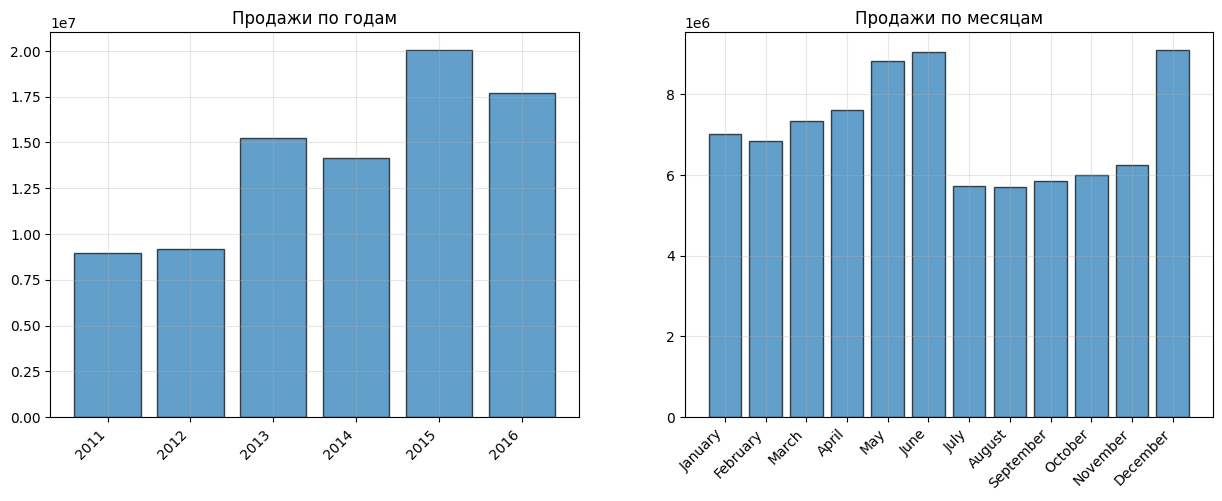

In [4]:
YearRevenue =  df[['Year','Revenue']]
YearRevenueArr = np.array(YearRevenue)

YearObj = {}
for item in YearRevenueArr:
    if item[0] in YearObj:
        YearObj[item[0]] += item[1]
    else:
        YearObj[item[0]] = item[1]
        
YearSorted = sorted(YearObj.items(), key=lambda x: x[0], reverse=True)
for key, value in YearSorted:
    print(f"{key}: {value}")
    
year = [item[0] for item in YearSorted]
yearSale = [item[1] for item in YearSorted]

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)    
plt.bar(year, yearSale, edgecolor='black',alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.title('Продажи по годам')

#############################################################

MonthRevenue =  df[['Month','Revenue']]
MonthRevenueArr = np.array(MonthRevenue)

MonthObj = {}
for item in MonthRevenueArr:
    if item[0] in MonthObj:
        MonthObj[item[0]] += item[1]
    else:
        MonthObj[item[0]] = item[1]

month_order = ['January', 'February', 'March', 'April', 'May', 'June','July', 'August', 'September', 'October', 'November', 'December']       
MonthSorted = sorted(MonthObj.items(), key=lambda x: month_order.index(x[0]))       
# MonthSorted = sorted(MonthObj.items(), key=lambda x: x[1], reverse=True)
for key, value in MonthSorted:
    print(f"{key}: {value}")
    
month = [item[0] for item in MonthSorted]
monthSale = [item[1] for item in MonthSorted]

plt.subplot(1, 2, 2)    
plt.bar(month, monthSale, edgecolor='black',alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.title('Продажи по месяцам')

plt.show()

## 5.	Вывести график соотношений Unit_Cost и Unit_Price

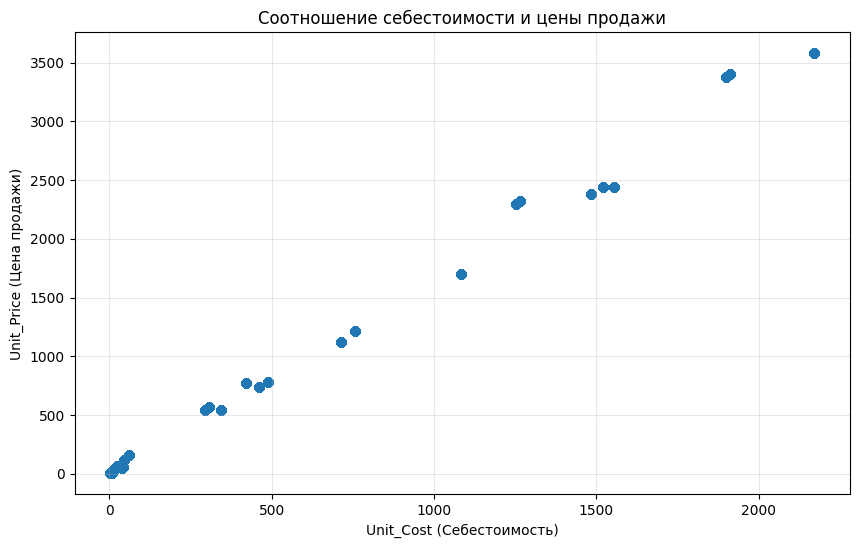

In [5]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Unit_Cost'], df['Unit_Price'],alpha=0.6)
plt.title('Соотношение себестоимости и цены продажи')
plt.xlabel('Unit_Cost (Себестоимость)')
plt.ylabel('Unit_Price (Цена продажи)')
plt.grid(True, alpha=0.3)

plt.show()

## 6.Построить линейную регрессию методом наименьших квадратов для данных из пункта 5

Уравнение: y = 1.6735 * x + 5.6280


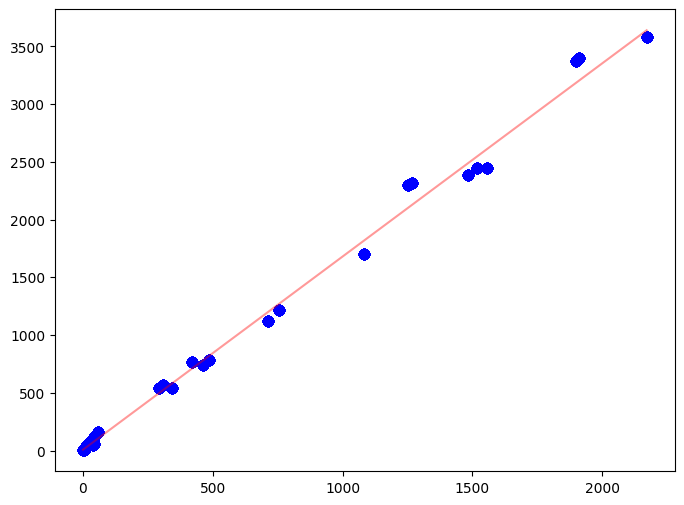

In [12]:
x = df['Unit_Cost'].values
y = df['Unit_Price'].values

n = len(x)
meanX = np.mean(x)
meanY = np.mean(y)

numerator = np.sum((x - meanX) * (y - meanY))
denominator = np.sum((x - meanX) ** 2)

slope = numerator / denominator
intercept = meanY - slope * meanX
y_pred = slope * x + intercept
print(f"Уравнение: y = {slope:.4f} * x + {intercept:.4f}")

plt.figure(figsize=(8, 6))
plt.scatter(x, y, color='blue',alpha=0.4, label='Исходные данные', s=50)
x_line = np.linspace(x.min(), x.max(), 100)
y_line = slope * x_line + intercept
plt.plot(x_line, y_line, color='red',alpha=0.4)
plt.show()


## 7.	Сравнить с линейной регрессией из пакета scikit-learn

In [26]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit([[item] for item in x], y)

slope_sklearn = model.coef_[0]
intercept_sklearn = model.intercept_
y_pred_sklearn = model.predict(x.reshape(-1, 1))

print(f"Scikit-learn уравнение: y = {slope_sklearn:.4f} * x + {intercept_sklearn:.4f}")

print(f"\nРазница в наклоне: {abs(slope - slope_sklearn):.10f}")
print(f"Разница в пересечении: {abs(intercept- intercept_sklearn):.10f}")



Scikit-learn уравнение: y = 1.6735 * x + 5.6280

Разница в наклоне: 0.0000000000
Разница в пересечении: 0.0000000001


## 8.	Построить график продаж по времени

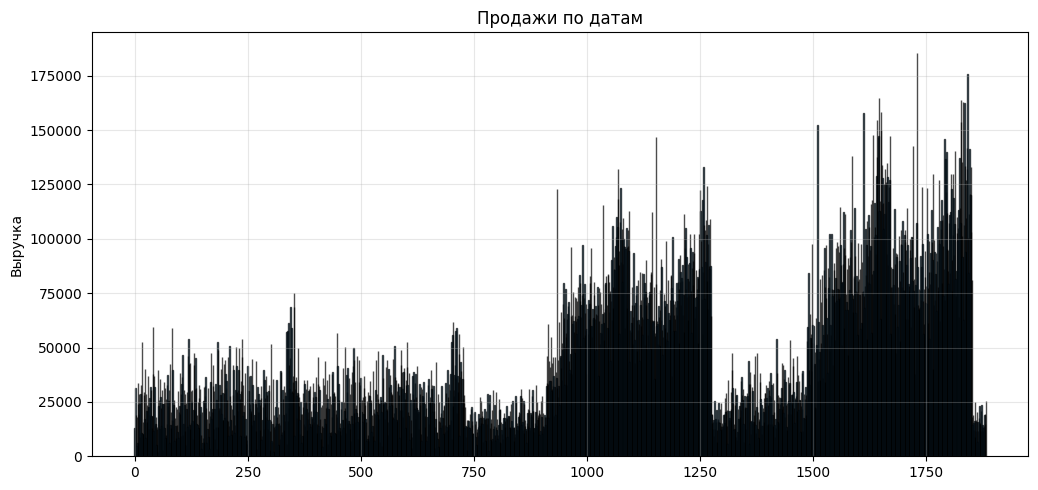

In [50]:
DateRevenue = df[['Date','Revenue']]
DateRevenueArr = np.array(DateRevenue)

DateObj = {}
for item in DateRevenueArr:
    date_str = item[0].strftime('%Y-%m-%d')  
    if date_str in DateObj:
        DateObj[date_str] += item[1]
    else:
        DateObj[date_str] = item[1]
        
DateSorted = sorted(DateObj.items(), key=lambda x: x[0])

dates = [item[0] for item in DateSorted]
dateSales = [item[1] for item in DateSorted]

plt.figure(figsize=(20, 5))

plt.subplot(1, 2, 1)    
plt.bar(range(len(dates)), dateSales, edgecolor='black', alpha=0.7)
# plt.xticks(range(len(dates)), dates, rotation=45, fontsize=5)
plt.grid(True, alpha=0.3)
plt.title('Продажи по датам')
plt.ylabel('Выручка')

plt.tight_layout()
plt.show()

